Loaded Zachary's Karate Club Graph:
  Nodes: 34 (0-33)
  Edges: 78


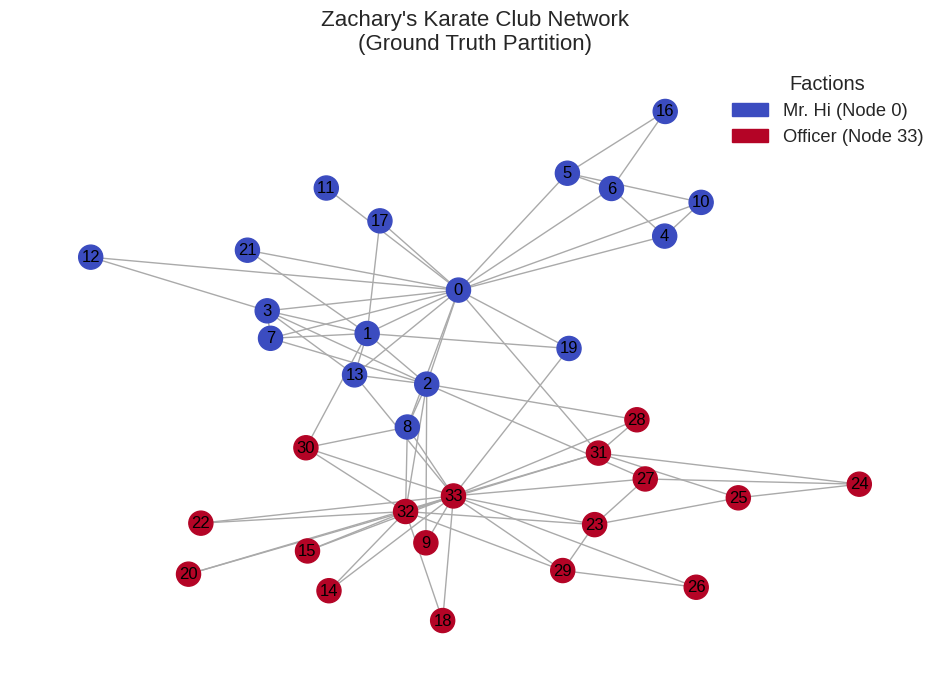

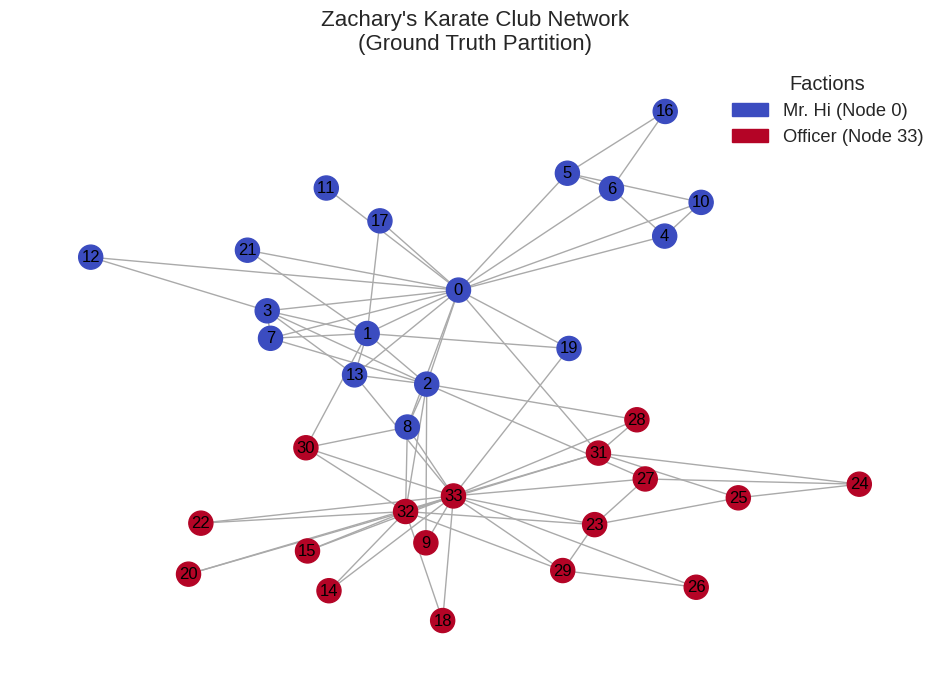

In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Set up plotting style for clarity
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)
%matplotlib inline

# Ensure deterministic layout for reproducibility
np.random.seed(42)
# --- Section 2: Graph Initialization ---

# Load the graph
G = nx.karate_club_graph()
N = G.number_of_nodes()
M = G.number_of_edges()
print(f"Loaded Zachary's Karate Club Graph:")
print(f"  Nodes: {N} (0-33)")
print(f"  Edges: {M}")

# Compute and store a fixed spring layout. This is ESSENTIAL for
# comparing the split visualizations later.
# k=0.3 increases repulsion to make the two clusters clearer.
pos = nx.spring_layout(G, k=0.3, iterations=50, seed=42)

# Extract the "ground truth" partition from the node attributes
# The 'club' attribute specifies 'Mr. Hi' or 'Officer'
ground_truth_map = {}
for node in G.nodes():
    club = G.nodes[node]['club']
    ground_truth_map[node] = club

# Create a list of 0s (Mr. Hi) and 1s (Officer) for coloring
ground_truth_colors = [0 if ground_truth_map[node] == 'Mr. Hi' else 1 for node in G.nodes()]
# --- Ground Truth Visualization ---

plt.figure(figsize=(12, 8))
ax = plt.gca()

# Draw the graph using the fixed layout and ground truth colors
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color=ground_truth_colors,
    cmap=plt.cm.coolwarm,
    edge_color="#AAAAAA",
    ax=ax
)

# Create a legend
mr_hi_patch = mpatches.Patch(color=plt.cm.coolwarm(0.0), label='Mr. Hi (Node 0)')
officer_patch = mpatches.Patch(color=plt.cm.coolwarm(1.0), label='Officer (Node 33)')
plt.legend(handles=[mr_hi_patch, officer_patch], title="Factions")

ax.set_title("Zachary's Karate Club Network\n(Ground Truth Partition)", fontsize=16)
plt.axis("off")
plt.show()# --- Ground Truth Visualization ---

plt.figure(figsize=(12, 8))
ax = plt.gca()

# Draw the graph using the fixed layout and ground truth colors
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color=ground_truth_colors,
    cmap=plt.cm.coolwarm,
    edge_color="#AAAAAA",
    ax=ax
)

# Create a legend
mr_hi_patch = mpatches.Patch(color=plt.cm.coolwarm(0.0), label='Mr. Hi (Node 0)')
officer_patch = mpatches.Patch(color=plt.cm.coolwarm(1.0), label='Officer (Node 33)')
plt.legend(handles=[mr_hi_patch, officer_patch], title="Factions")

ax.set_title("Zachary's Karate Club Network\n(Ground Truth Partition)", fontsize=16)
plt.axis("off")
plt.show()
